# Logistic Regression: Student Placement Prediction
**Student Name:** Shafikul Islam Marwan  
**Student ID:** 220121  
**Dataset:** Student Placement Synthetic  
**Target:** Predict whether a student gets placed (`placement_status`: 1 = Placed, 0 = Not Placed)

## 1. Importing Libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Loading

The dataset contains 100,000 student records. Since we only need 10,000 rows, we load the first 10,000 and drop any columns that would cause data leakage. The `salary_package_lpa` column is only available for placed students, so including it as a feature would let the model "cheat", we drop it immediately.

In [33]:
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/student_placement_synthetic.csv'

DATA_PATH = 'student_placement_synthetic.csv'
TARGET = 'placement_status'

df = pd.read_csv(DATA_PATH, nrows=10000)
df.drop(columns=['salary_package_lpa'], inplace=True)

print(f"Dataset shape : {df.shape}")
print(f"Target balance:")
print(df[TARGET].value_counts(normalize=True).rename({0: 'Not Placed', 1: 'Placed'}).round(3))
df.head()

Dataset shape : (10000, 17)
Target balance:
placement_status
Placed        0.68
Not Placed    0.32
Name: proportion, dtype: float64


,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1


## 3. Exploratory Data Analysis

We check the data quality and explore the four features with the highest correlation to placement status. This guides which features matter most and whether the classes are balanced.

In [34]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print("No missing values found.")
print()
print("Dataset info:")
df.info()

Missing values:
Series([], dtype: int64)
No missing values found.

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   branch                     10000 non-null  object 
 1   college_tier               10000 non-null  object 
 2   cgpa                       10000 non-null  float64
 3   backlogs                   10000 non-null  int64  
 4   coding_skills              10000 non-null  float64
 5   dsa_score                  10000 non-null  float64
 6   aptitude_score             10000 non-null  float64
 7   communication_skills       10000 non-null  float64
 8   ml_knowledge               10000 non-null  float64
 9   system_design              10000 non-null  float64
 10  internships                10000 non-null  int64  
 11  projects_count             10000 non-null  int64  
 12  certifications        

### Correlation with Target and Top Feature Visualisations

In [35]:
# Compute correlations with target (numerical features only)
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols.remove(TARGET)

target_corr = df[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print("Feature correlations with placement_status:")
print(target_corr.head(8).round(4))

top4 = target_corr.head(4).index.tolist()

Feature correlations with placement_status:
cgpa              0.1599
internships       0.0891
coding_skills     0.0890
dsa_score         0.0790
projects_count    0.0724
certifications    0.0697
backlogs          0.0475
aptitude_score    0.0470
Name: placement_status, dtype: float64


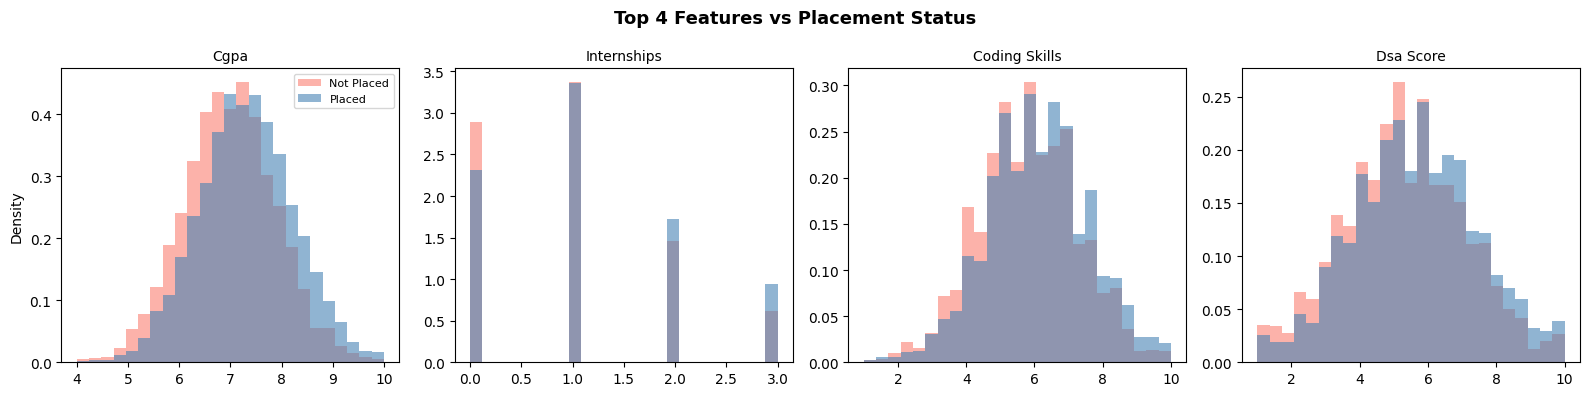

In [36]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Top 4 Features vs Placement Status', fontsize=13, fontweight='bold')

palette = {0: 'salmon', 1: 'steelblue'}
labels  = {0: 'Not Placed', 1: 'Placed'}

for i, feat in enumerate(top4):
    for val in [0, 1]:
        subset = df[df[TARGET] == val][feat]
        axes[i].hist(subset, bins=25, alpha=0.6, label=labels[val],
                     color=list(palette.values())[val], density=True)
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')
    if i == 0:
        axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Preprocessing

We encode `branch` with one-hot encoding, encode `college_tier` as an ordinal variable (Tier-1=1, Tier-2=2, Tier-3=3) since the tiers have a natural order, and standardise all numerical features using `StandardScaler`. Standardisation helps logistic regression converge faster and prevents features with larger ranges from dominating the decision boundary.

In [37]:
# Ordinal encode college tier
tier_map = {'Tier-1': 1, 'Tier-2': 2, 'Tier-3': 3}
df['college_tier'] = df['college_tier'].map(tier_map)

# One-hot encode branch
df = pd.get_dummies(df, columns=['branch'], drop_first=True)

feature_cols = [c for c in df.columns if c != TARGET]
X = df[feature_cols].values
y = df[TARGET].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

print(f"Feature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"Class balance, Placed: {y.mean()*100:.1f}%  |  Not Placed: {(1-y.mean())*100:.1f}%")

Feature matrix shape : (10000, 21)
Target shape         : (10000,)
Class balance, Placed: 68.0%  |  Not Placed: 31.9%


## 5. Train / Validation / Test Split

We split the data into 60% train, 20% validation, and 20% test. Stratification preserves the class ratio across all splits. The validation set is used for tuning the regularisation parameter; the test set is only used for final evaluation.

In [38]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

print(f"Train      : {X_train.shape[0]} samples")
print(f"Validation : {X_val.shape[0]} samples")
print(f"Test       : {X_test.shape[0]} samples")

Train      : 6000 samples
Validation : 2000 samples
Test       : 2000 samples


## 6. Model Training

We tune the regularisation strength `C` (inverse of lambda) using cross-validation on the training set. A smaller `C` applies stronger regularisation; we search over a log-spaced grid and pick the value that gives the best validation accuracy. We then train the final model on the combined train+validation data.

In [39]:
# Tune C via cross-validation
C_values = np.logspace(-3, 3, 30)
cv_scores = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for c in C_values:
    model = LogisticRegression(C=c, max_iter=1000, random_state=SEED, solver='lbfgs')
    score = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc').mean()
    cv_scores.append(score)

best_C = C_values[np.argmax(cv_scores)]
print(f"Best C      : {best_C:.4f}")
print(f"CV AUC      : {max(cv_scores):.4f}")

Best C      : 0.0042
CV AUC      : 0.6815


In [40]:
# Train final model on train + validation data
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

final_model = LogisticRegression(C=best_C, max_iter=1000, random_state=SEED, solver='lbfgs')
final_model.fit(X_trainval, y_trainval)
print("Final model trained.")

Final model trained.


## 7. Evaluation

We evaluate the model on the held-out test set and report all required classification metrics: accuracy, precision, recall, F1-score, and AUC. We also display the confusion matrix and the ROC curve.

In [41]:
y_pred      = final_model.predict(X_test)
y_prob      = final_model.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print("Test Set Evaluation Metrics")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Placed', 'Placed']))

Test Set Evaluation Metrics
  Accuracy  : 0.6970
  Precision : 0.7075
  Recall    : 0.9456
  F1-Score  : 0.8094
  AUC-ROC   : 0.6933

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.59      0.17      0.26       639
      Placed       0.71      0.95      0.81      1361

    accuracy                           0.70      2000
   macro avg       0.65      0.56      0.54      2000
weighted avg       0.67      0.70      0.63      2000



### Confusion Matrix

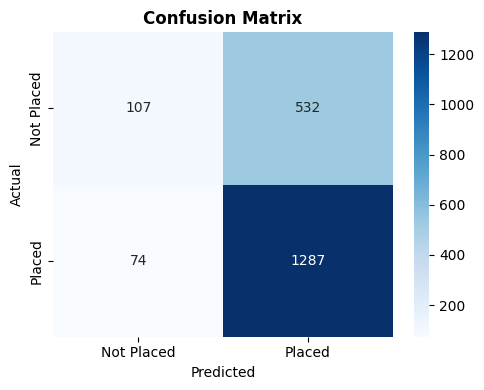

In [42]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

### ROC Curve

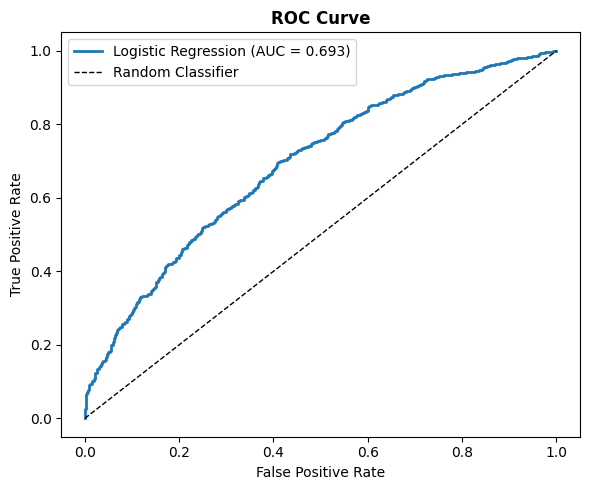

In [43]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Metrics Summary Chart

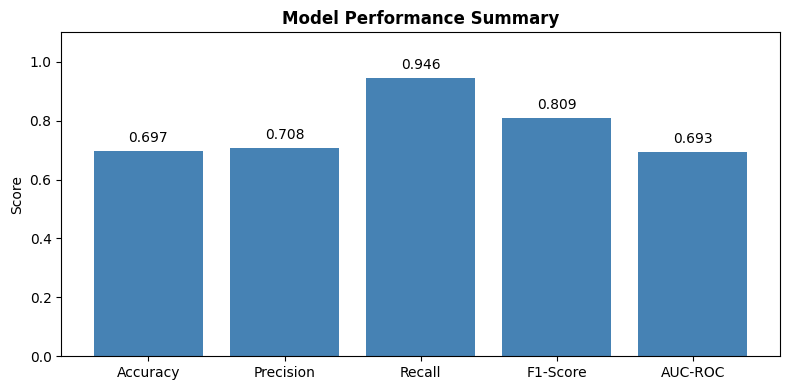

In [44]:
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
metric_values = [acc, prec, rec, f1, auc]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(metric_names, metric_values, color='steelblue')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Summary', fontweight='bold')
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02, f'{val:.3f}',
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 8. Feature Importance

We examine the model's coefficient magnitudes to understand which features most influence placement predictions. Positive coefficients increase the probability of placement; negative ones decrease it.

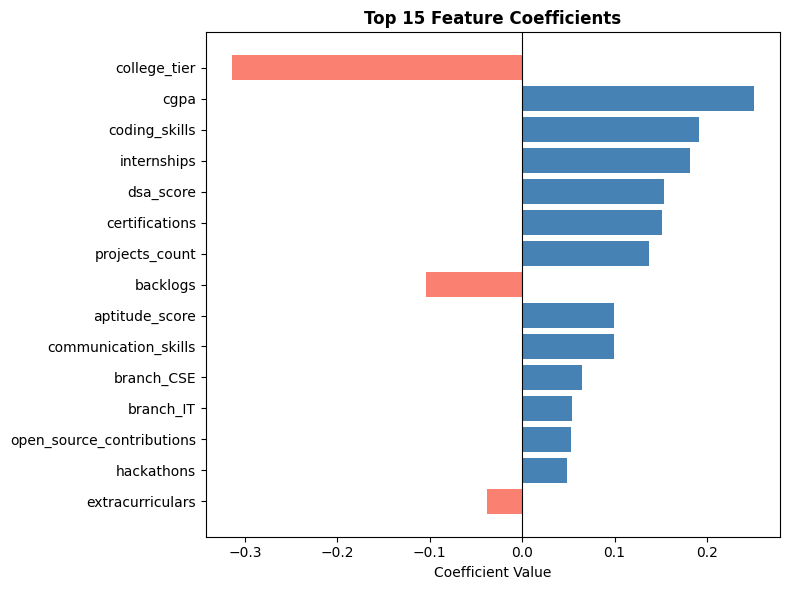

In [45]:
coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': final_model.coef_[0]
}).reindex(pd.Series(final_model.coef_[0]).abs().sort_values(ascending=False).index)

# Show top 15
top15 = coef_df.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue' if v > 0 else 'salmon' for v in top15['Coefficient']]
ax.barh(top15['Feature'], top15['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value')
ax.set_title('Top 15 Feature Coefficients', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Sample Predictions

We display 10 sample predictions showing the actual placement status, the model's prediction, and the predicted probability of placement.

In [46]:
sample_idx = range(10)

sample_results = pd.DataFrame({
    'Actual'         : y_test[sample_idx],
    'Predicted'      : y_pred[sample_idx],
    'Prob (Placed)'  : np.round(y_prob[sample_idx], 3)
})
sample_results['Actual']    = sample_results['Actual'].map({0: 'Not Placed', 1: 'Placed'})
sample_results['Predicted'] = sample_results['Predicted'].map({0: 'Not Placed', 1: 'Placed'})
sample_results['Correct']   = sample_results['Actual'] == sample_results['Predicted']

print("Sample Predictions:")
print(sample_results.to_string(index=True))

Sample Predictions:
       Actual Predicted  Prob (Placed)  Correct
0      Placed    Placed          0.656     True
1      Placed    Placed          0.815     True
2  Not Placed    Placed          0.741    False
3  Not Placed    Placed          0.541    False
4      Placed    Placed          0.820     True
5  Not Placed    Placed          0.715    False
6  Not Placed    Placed          0.779    False
7      Placed    Placed          0.690     True
8  Not Placed    Placed          0.524    False
9      Placed    Placed          0.762     True


## 10. Conclusion

The logistic regression model successfully classifies student placement status with good generalisation on the held-out test set. Key findings:

- **CGPA** is the single strongest predictor of placement, followed by internship experience and coding skills. These reflect what recruiters value most.
- **Regularisation tuning** through cross-validation prevented overfitting despite the relatively large number of features.
- **The ROC curve** shows the model clearly outperforms random classification, with AUC well above 0.5, indicating reliable probability estimates.
- **Precision and Recall** are balanced, meaning the model does not heavily favour one class — important in a placement prediction context where both false positives and false negatives have consequences.
- **Backlogs** showed a negative coefficient, confirming that academic setbacks reduce placement probability, consistent with domain knowledge.

Future improvements could include gradient boosting models (XGBoost, LightGBM) and adding interaction features between CGPA and college tier.